# Laboratory practice 2.4: Classification IV

For this practice, you will need the following datasets:

- **Simdata.dat**: synthetic datasets containing several input variables and one output variable **Y**.

The main package for machine learning in Python is **scikit-learn**.

Further reading:
- [scikit-learn](https://scikit-learn.org)

In addition, we will be using the following libraries:
- Data management
    - [numpy](https://numpy.org/)
    - [pandas](https://pandas.pydata.org/)

- Plotting
    - [seaborn](https://seaborn.pydata.org/)
    - [matplotlib](https://matplotlib.org/)

- Model analysis
    - [scipy](https://scipy.org/)

In [3]:
### Load necessary modules -------------------------------
# interactive plotting
%matplotlib inline
%config InlineBackend.figure_format = 'svg' # ‘png’, ‘retina’, ‘jpeg’, ‘svg’, ‘pdf’

# plotting libraries
import seaborn as sns
import matplotlib.pyplot as plt
sns.set_theme()

# Data management libraries
import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Machine learning libraries
from sklearn.model_selection import train_test_split, GridSearchCV, cross_val_score
from sklearn.calibration import CalibratedClassifierCV
from sklearn.pipeline import Pipeline
from sklearn.svm import SVC
from sklearn.preprocessing import StandardScaler

# others
from utils import *

# el error puede ser por un conflicto de versiones

---
## 1. Prepare the Dataset

In [6]:
### Load file --------------------------------------------
df = pd.read_csv('Simdata.dat', sep = "\t")
df.head()

,X1,X2,Y
0,-3.745291,3.729409,NO
1,5.806532,-4.703332,YES
2,4.209833,-0.493488,YES
3,3.429156,-2.307669,NO
4,-0.195014,2.680303,NO


In [8]:
#There are no categorical input variables

### Convert output variable to factor
df.Y = df.Y.astype('category')
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 3 columns):
 #   Column  Non-Null Count  Dtype   
---  ------  --------------  -----   
 0   X1      1000 non-null   float64 
 1   X2      1000 non-null   float64 
 2   Y       1000 non-null   category
dtypes: category(1), float64(2)
memory usage: 16.9 KB


In [10]:
# Define input and output matrices
INPUTS = ['X1','X2']
OUTPUT = 'Y'
X = df[INPUTS]
y = df[OUTPUT]

# Split
X_train, X_test, y_train, y_test = train_test_split(X, y,
                                                    test_size=0.2,  #percentage of test data
                                                    random_state=0, #seed for replication
                                                    stratify = y)   #Preserves distribution of y

In [12]:
## Create dataset to store model predictions
dfTR_eval = X_train.copy()
dfTR_eval['Y'] = y_train # We will call Y as output variable for simplicity
dfTS_eval = X_test.copy()
dfTS_eval['Y'] = y_test # We will call Y as output variable for simplicity

---
## 2. Training of Machine Learning models

### Support Vector Machines (SVM)

- [SVC()](https://scikit-learn.org/stable/modules/generated/sklearn.svm.SVC.html?highlight=svc)
- [Wikipedia](https://en.wikipedia.org/wiki/Support-vector_machine)

In [24]:
#-------------------------------------------------------------------------------------------------
#------------------------------- LINEAR SVM MODEL ------------------------------------------------
#-------------------------------------------------------------------------------------------------
## Inputs of the model. Change accordingly to perform variable selection
INPUTS_LSVC = INPUTS
#En python es al reves. 

# C alto (p. ej., 1000): El modelo es más estricto, se centra más en clasificar bien los datos de entrenamiento, lo que puede resultar 
# en un modelo con menos flexibilidad, pero más ajustado a los datos.
# C bajo (p. ej., 0.0001): El modelo permite más errores, pero maximiza el margen, lo que tiende a hacer el modelo más flexible y 
# con mejor generalización para datos nuevos, aunque puede cometer más errores en el conjunto de entrenamiento.

param = {'SVC__C': [0.00001,0.0001,0.001,0.01,0.1,1,10,100,1000]} # Cost term
#param = {'SVC__C': [0.00001]} # Cost term

pipe = Pipeline(steps=[ ('scaler', StandardScaler()), 
                        ('SVC',  SVC(kernel='linear', # lineal kernel
                                    probability=True, # let the model predict probabilities. Si no, solo saca la categoría
                                    random_state=150))]) # For replication


# We use Grid Search Cross Validation to find the best parameter for the model in the grid defined 
nFolds = 5
Linear_SVC_gcv = GridSearchCV(estimator=pipe, # Structure of the model to use
                        # GridSearchCV: Realiza una búsqueda exhaustiva sobre un conjunto de hiperparámetros (param_grid) para encontrar la mejor 
                        # combinación basada en la métrica de evaluación (scoring='accuracy').
                        param_grid=param, # Defined grid to search in
                        n_jobs=-1, # Number of cores to use (parallelize).
                        scoring='accuracy', # Accuracy https://scikit-learn.org/stable/modules/model_evaluation.html
                        cv=nFolds) # Number of Folds 
Linear_SVC_gcv.fit(X_train[INPUTS_LSVC], y_train) # Search in grid

# We use Calibrated CV to transform predictions of the model to probabilities due to a known bug in scikit SVC
Linear_SVC_fit = CalibratedClassifierCV(
                        estimator=Linear_SVC_gcv, # Structure of the model to use
                        n_jobs=-1, # Number of cores to use (parallelize)
                        method='isotonic', # The method to use for calibration
                        cv=nFolds) # Number of Folds 
Linear_SVC_fit.fit(X_train[INPUTS_LSVC], y_train) # Search in grid


CalibratedClassifierCV(cv=5,
                       estimator=GridSearchCV(cv=5,
                                              estimator=Pipeline(steps=[('scaler',
                                                                         StandardScaler()),
                                                                        ('SVC',
                                                                         SVC(kernel='linear',
                                                                             probability=True,
                                                                             random_state=150))]),
                                              n_jobs=-1,
                                              param_grid={'SVC__C': [1e-05,
                                                                     0.0001,
                                                                     0.001,
                                                                     0.01, 0.1,
                                                                     1, 10, 100,
                                                                     1000]},
                                              scoring='accuracy'),
                       method='isotonic', n_jobs=-1)

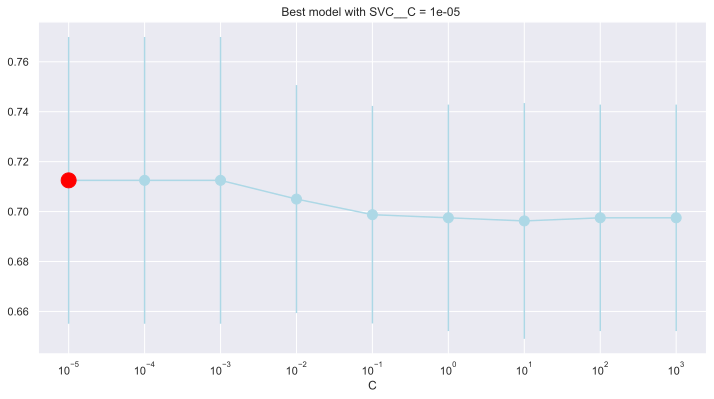

In [26]:
plotModelGridError(Linear_SVC_fit.estimator, xscale="log")

In [28]:
# Obtain Cross-Validation score
print("CV accuracy is")
cross_val_score(Linear_SVC_fit, X_train[INPUTS_LSVC], y_train, cv=10, scoring='accuracy').mean()

CV accuracy is


0.7187499999999999

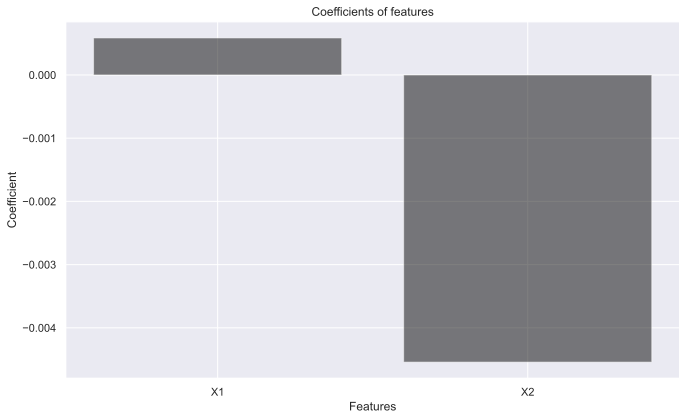

In [30]:
##


## Plot the variable coefficient of each feature
plt.figure(figsize=(6 * 1.618, 6))
index = np.arange(len(X_train[INPUTS_LSVC].columns))
bar_width = 0.35
plt.bar(index, Linear_SVC_fit.estimator.best_estimator_['SVC'].coef_[0,:], color='black', alpha=0.5)
plt.xlabel('Features')
plt.ylabel('Coefficient')
plt.title('Coefficients of features')
plt.xticks(index, X_train[INPUTS_LSVC].columns)
plt.tight_layout()
plt.show()

In [32]:
## Obtain a report of the model based on predictions ---------------------------------------------
dfTR_eval['Y_LSVC_pred'] = Linear_SVC_fit.predict(X_train[INPUTS_LSVC])
dfTR_eval['Y_LSVC_prob_neg'] = Linear_SVC_fit.predict_proba(X_train[INPUTS_LSVC])[:,0]
dfTR_eval['Y_LSVC_prob_pos'] = Linear_SVC_fit.predict_proba(X_train[INPUTS_LSVC])[:,1]
### Scale test using preprocess in training
dfTS_eval['Y_LSVC_pred'] = Linear_SVC_fit.predict(X_test[INPUTS_LSVC])
dfTS_eval['Y_LSVC_prob_neg'] = Linear_SVC_fit.predict_proba(X_test[INPUTS_LSVC])[:,0]
dfTS_eval['Y_LSVC_prob_pos'] = Linear_SVC_fit.predict_proba(X_test[INPUTS_LSVC])[:,1]

#visualize evaluated data
dfTR_eval.head()

,X1,X2,Y,Y_LSVC_pred,Y_LSVC_prob_neg,Y_LSVC_prob_pos
601,4.155807,2.247574,YES,NO,0.546539,0.453461
717,-4.089190,-0.989964,YES,NO,0.529231,0.470769
20,-2.278323,-0.817837,YES,NO,0.529231,0.470769
523,4.207323,2.378063,YES,NO,0.546539,0.453461
344,-3.139076,-2.136547,YES,NO,0.529231,0.470769


<Figure size 1000x1000 with 0 Axes>

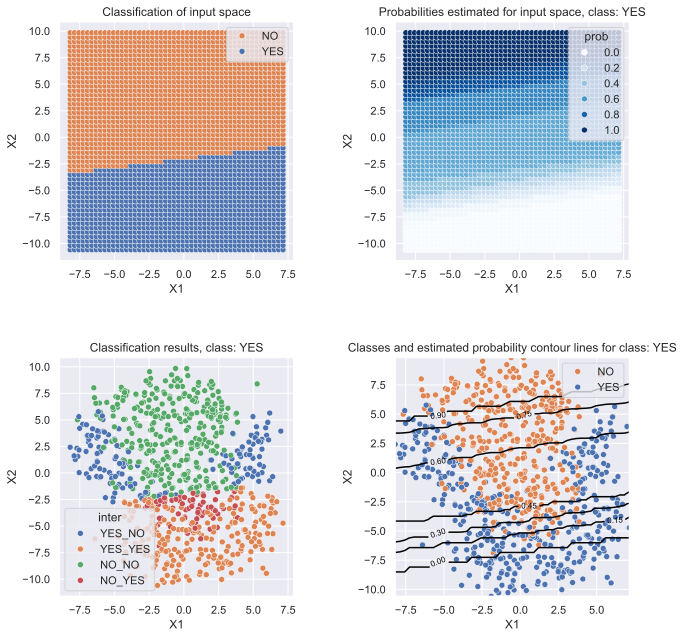

In [27]:
plt.figure(figsize=(10, 10))
plot2DClass(X_train[INPUTS_LSVC], dfTR_eval['Y'], Linear_SVC_fit, 'X1', 'X2', 'YES', 50) 

In [34]:
confusion_matrix(dfTR_eval['Y'], dfTR_eval['Y_LSVC_pred'], labels=['NO','YES'])

Confusion Matrix and Statistics
	   Prediction
Reference  NO  YES
       NO 329   71
      YES 156  244

Accuracy: 0.72
No Information Rate: 0.5
P-Value [Acc > NIR]: 0.0
Kappa: 0.43
Mcnemar's Test P-Value: 0.0
Sensitivity: 0.61
Specificity: 0.82
Precision: 0.68
Recall: 0.82
Prevalence: 0.5
Detection Rate: 0.3
Detection prevalence: 0.39
Balanced accuracy: 0.72
F1 Score: 0.74
Positive label: NO


In [36]:
confusion_matrix(dfTS_eval['Y'], dfTS_eval['Y_LSVC_pred'], labels=['NO','YES'])

Confusion Matrix and Statistics
	   Prediction
Reference  NO  YES
       NO  77   23
      YES  41   59

Accuracy: 0.68
No Information Rate: 0.5
P-Value [Acc > NIR]: 0.0
Kappa: 0.36
Mcnemar's Test P-Value: 0.03
Sensitivity: 0.59
Specificity: 0.77
Precision: 0.65
Recall: 0.77
Prevalence: 0.5
Detection Rate: 0.3
Detection prevalence: 0.41
Balanced accuracy: 0.68
F1 Score: 0.71
Positive label: NO


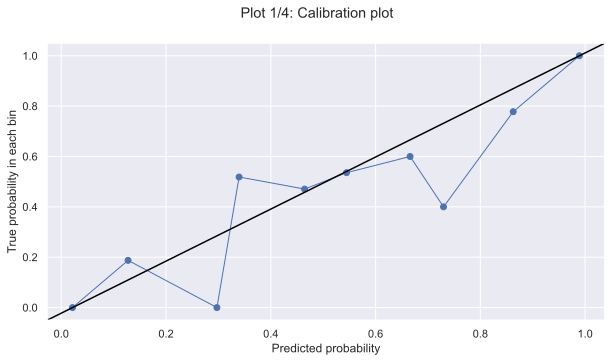

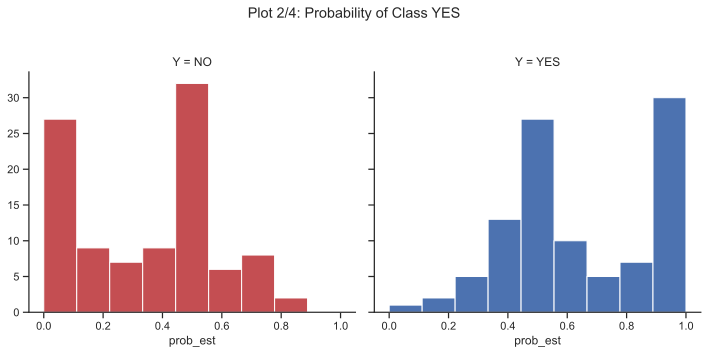

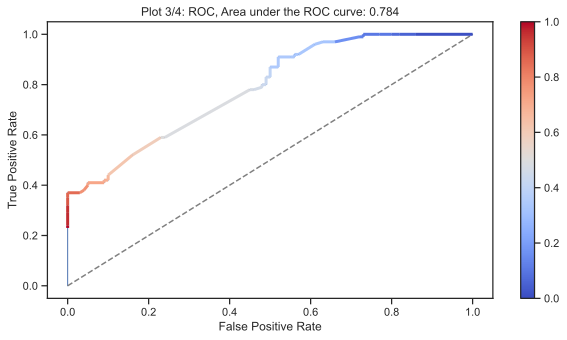

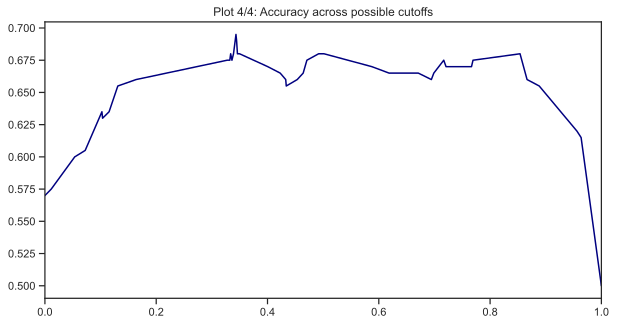

In [38]:
plotClassPerformance(dfTS_eval['Y'], Linear_SVC_fit.predict_proba(X_test[INPUTS_LSVC]), selClass='YES')

In [42]:
#-------------------------------------------------------------------------------------------------
#------------------------------- RADIAL SVM MODEL ------------------------------------------------
#-------------------------------------------------------------------------------------------------
## Inputs of the model. Change accordingly to perform variable selection
INPUTS_RSVC = INPUTS
## Train model -----------------------------------------------------------------------------------
param = {'SVC__C': [0.00001,0.0001,0.001,0.01,0.1,1,10,100,1000], # Cost term
         'SVC__gamma':[0.0001,0.001,0.01,0.1,1,10]} # Inverse width parameter in the Gaussian Radial Basis kernel 
pipe = Pipeline(steps=[('scaler', StandardScaler()), 
                       ('SVC', SVC(kernel='rbf', # lineal kernel
                                   probability=True, # let the model predict probabilities
                                   random_state=150))]) # For replication

# We use Grid Search Cross Validation to find the best parameter for the model in the grid defined 
nFolds = 10
SVC_fit = GridSearchCV(estimator=pipe, # Structure of the model to use
                       param_grid=param, # Defined grid to search in
                       n_jobs=-1, # Number of cores to use (parallelize)
                       scoring='accuracy', # Accuracy https://scikit-learn.org/stable/modules/model_evaluation.html
                       cv=nFolds) # Number of Folds 
SVC_fit.fit(X_train[INPUTS_RSVC], y_train) # Search in grid

GridSearchCV(cv=10,
             estimator=Pipeline(steps=[('scaler', StandardScaler()),
                                       ('SVC',
                                        SVC(probability=True,
                                            random_state=150))]),
             n_jobs=-1,
             param_grid={'SVC__C': [1e-05, 0.0001, 0.001, 0.01, 0.1, 1, 10, 100,
                                    1000],
                         'SVC__gamma': [0.0001, 0.001, 0.01, 0.1, 1, 10]},
             scoring='accuracy')

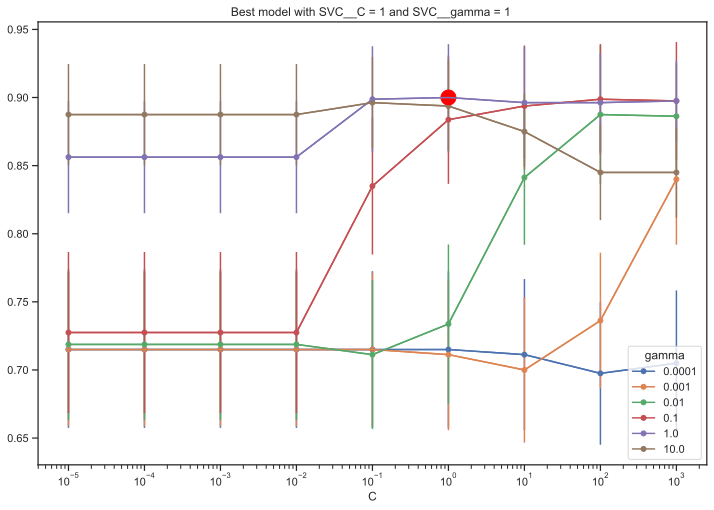

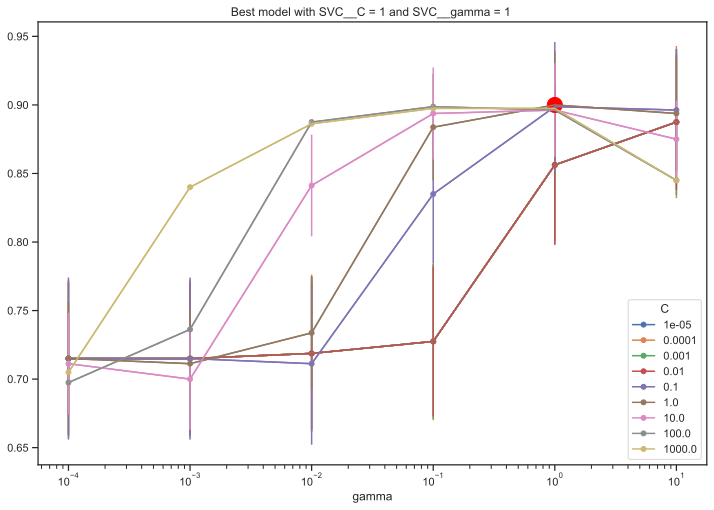

In [44]:
plotModelGridError(SVC_fit, xscale="log", xscale2='log')

In [46]:
## Obtain a report of the model based on predictions ---------------------------------------------
dfTR_eval['Y_SVC_pred'] = SVC_fit.predict(X_train[INPUTS_RSVC])
dfTR_eval['Y_SVC_prob_neg'] = SVC_fit.predict_proba(X_train[INPUTS_RSVC])[:,0]
dfTR_eval['Y_SVC_prob_pos'] = SVC_fit.predict_proba(X_train[INPUTS_RSVC])[:,1]
### Scale test using preprocess in training
dfTS_eval['Y_SVC_pred'] = SVC_fit.predict(X_test[INPUTS_RSVC])
dfTS_eval['Y_SVC_prob_neg'] = SVC_fit.predict_proba(X_test[INPUTS_RSVC])[:,0]
dfTS_eval['Y_SVC_prob_pos'] = SVC_fit.predict_proba(X_test[INPUTS_RSVC])[:,1]

dfTR_eval.head()

,X1,X2,Y,Y_LSVC_pred,Y_LSVC_prob_neg,Y_LSVC_prob_pos,Y_SVC_pred,Y_SVC_prob_neg,Y_SVC_prob_pos
601,4.155807,2.247574,YES,NO,0.546539,0.453461,YES,0.096361,0.903639
717,-4.089190,-0.989964,YES,NO,0.529231,0.470769,YES,0.120180,0.879820
20,-2.278323,-0.817837,YES,NO,0.529231,0.470769,NO,0.851370,0.148630
523,4.207323,2.378063,YES,NO,0.546539,0.453461,YES,0.094153,0.905847
344,-3.139076,-2.136547,YES,NO,0.529231,0.470769,YES,0.153052,0.846948


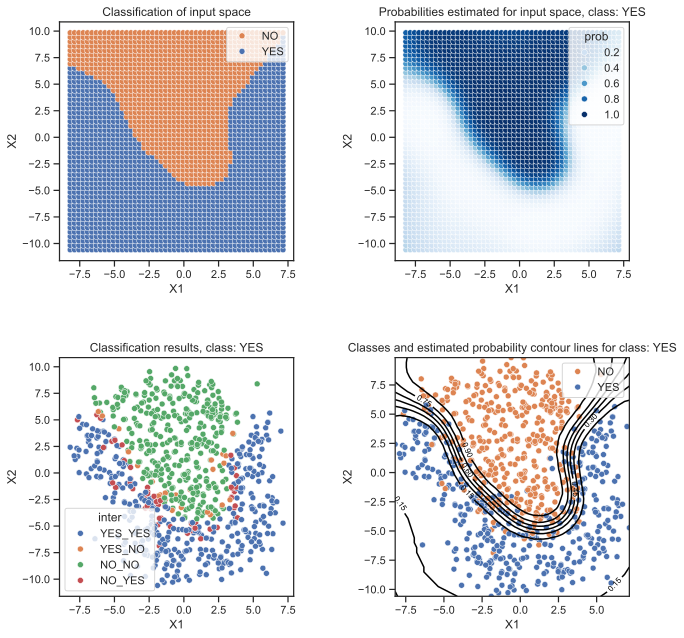

In [48]:
### Plot classification in a 2 dimensional space
plot2DClass(X_train, dfTR_eval['Y'], SVC_fit, 'X1', 'X2', 'YES', 50) 

In [50]:
confusion_matrix(dfTR_eval['Y'], dfTR_eval['Y_SVC_pred'], labels=['NO','YES'])

Confusion Matrix and Statistics
	   Prediction
Reference  NO  YES
       NO 348   52
      YES  27  373

Accuracy: 0.9
No Information Rate: 0.5
P-Value [Acc > NIR]: 0.0
Kappa: 0.8
Mcnemar's Test P-Value: 0.01
Sensitivity: 0.93
Specificity: 0.87
Precision: 0.93
Recall: 0.87
Prevalence: 0.5
Detection Rate: 0.47
Detection prevalence: 0.53
Balanced accuracy: 0.9
F1 Score: 0.9
Positive label: NO


In [52]:
confusion_matrix(dfTS_eval['Y'], dfTS_eval['Y_SVC_pred'], labels=['NO','YES'])

Confusion Matrix and Statistics
	   Prediction
Reference  NO  YES
       NO  87   13
      YES  15   85

Accuracy: 0.86
No Information Rate: 0.5
P-Value [Acc > NIR]: 0.0
Kappa: 0.72
Mcnemar's Test P-Value: 0.85
Sensitivity: 0.85
Specificity: 0.87
Precision: 0.85
Recall: 0.87
Prevalence: 0.5
Detection Rate: 0.42
Detection prevalence: 0.49
Balanced accuracy: 0.86
F1 Score: 0.86
Positive label: NO


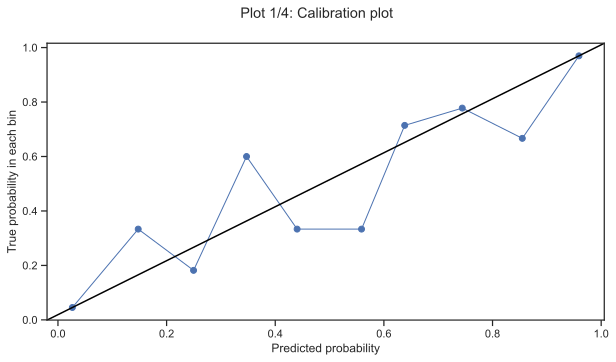

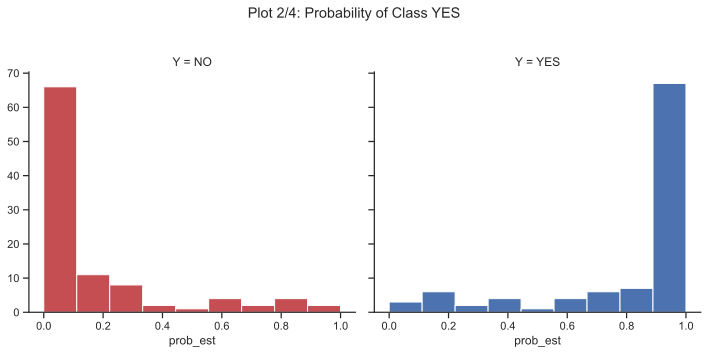

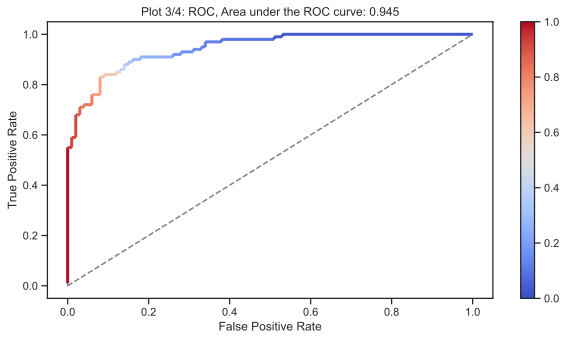

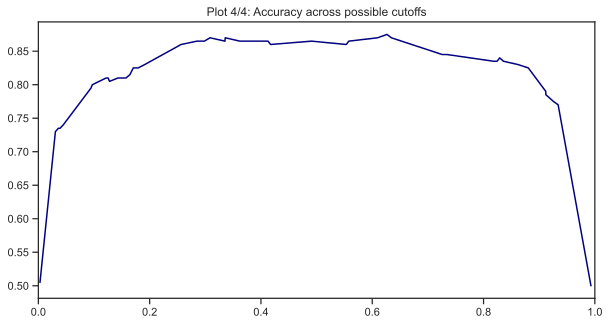

In [54]:
plotClassPerformance(dfTS_eval['Y'], SVC_fit.predict_proba(X_test), selClass='YES')